# Base Learner: 1D-CNN on the Fused Feature Vector

A third base learner: a small 1D convolutional network over the 1287-dimensional fused vector, treated as a length-1287 single-channel signal. Regularised with **dropout** and **early stopping**.

Unlike the tree learners, a CNN is gradient-based and scale-sensitive, so the fused vector is standardised first (scaler fit on the training split only). Early stopping uses a validation set carved out of **train** — the held-out test set is never seen during training.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch, torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (accuracy_score, roc_auc_score, matthews_corrcoef,
                             f1_score, recall_score, precision_score,
                             confusion_matrix, roc_curve)

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
device = ("cuda" if torch.cuda.is_available()
          else "mps" if torch.backends.mps.is_available() else "cpu") # mps means Metal Performance Shaders (Apple Silicon GPU)
print("device:", device)

device: mps


## 1. Load and standardise the fused vectors

In [6]:
d = np.load("fusion_vectors.npz", allow_pickle=True)
X, y, split = d["X"].astype("float32"), d["label"].astype("float32"), d["split"]
tr, te = split == "train", split == "test" # no need for sklearn.train_test_split since the dataset is already split into train and test sets

scaler = StandardScaler().fit(X[tr])          # fit on train only
Xtr_all, Xte = scaler.transform(X[tr]), scaler.transform(X[te]) # transform the train and test data
ytr_all, yte = y[tr], y[te]
print(f"train {Xtr_all.shape}  test {Xte.shape}")

train (1754, 1287)  test (178, 1287)


## 2. Define the 1D-CNN

In [7]:
class FusionCNN(nn.Module):
    def __init__(self, n_feat=1287, p=0.4):
        super().__init__()
        # Treat the 1287-d fused vector as a 1-channel signal of length 1287.
        # Two conv blocks learn local feature combinations; pooling shrinks the length.
        # B peptides, each a 1-channel signal of length 1287. If batch is 64 peptides, B = 64 → [64, 1, 1287].
        self.conv = nn.Sequential(
            nn.Conv1d(1, 32, 7, padding=3),   # 1 -> 32 channels, kernel 7 (pad keeps length) [B,32,1287]
            nn.BatchNorm1d(32), nn.ReLU(),    # normalise per channel, then non-linearity
            nn.MaxPool1d(2), nn.Dropout(p),   # halve length -> [B,32,643]; dropout = regularisation
            nn.Conv1d(32, 64, 5, padding=2),  # 32 -> 64 channels, kernel 5                    [B,64,643]
            nn.BatchNorm1d(64), nn.ReLU(),
            nn.MaxPool1d(2), nn.Dropout(p),   # halve again -> [B,64,321]
            nn.AdaptiveAvgPool1d(1))          # average over length -> fixed [B,64,1] (length-independent)
        
        # Classifier head: 64 features -> hidden 32 -> single logit.
        self.head = nn.Sequential(
            nn.Flatten(),                     # [B,64,1] -> [B,64]
            nn.Linear(64, 32), nn.ReLU(),
            nn.Dropout(p),
            nn.Linear(32, 1))                 # -> [B,1]  (one raw logit per sample)

    def forward(self, x):                     # x: [B, 1, n_feat]
        return self.head(self.conv(x)).squeeze(1)   # [B,1] -> [B]: one logit per peptide

## 3. Training routine with early stopping

Trains on a train/validation split, monitors validation loss, keeps the best weights,
and stops when validation stops improving for `patience` epochs.

In [8]:
def fit_cnn(Xtr, ytr, seed=SEED, max_epochs=200, patience=15, return_history=False):
    torch.manual_seed(seed)                          # reproducible init/dropout per call
    # Carve a 15% internal validation set (stratified) to drive early stopping.
    xtr, xval, ytr_, yval = train_test_split(Xtr, ytr, test_size=0.15,
                                             stratify=ytr, random_state=seed)
    to = lambda a: torch.tensor(a, dtype=torch.float32, device=device)  # numpy -> tensor on device
    xtr_t, xval_t = to(xtr).unsqueeze(1), to(xval).unsqueeze(1)   # add channel dimensions -> [B, 1, n_feat]
    ytr_t, yval_t = to(ytr_), to(yval)

    model = FusionCNN(Xtr.shape[1]).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)  # wd = L2 regularisation
    loss_fn = nn.BCEWithLogitsLoss()

    # Early-stopping things to note: best val loss, best weights, epochs-since-improvement, history.
    best, best_state, wait, hist = np.inf, None, 0, []
    for epoch in range(max_epochs):
        model.train()                                
        for i in range(0, len(xtr_t), 64):           # mini-batches of 64
            opt.zero_grad()                          # clear gradients from the previous step
            out = model(xtr_t[i:i+64])
            loss_fn(out, ytr_t[i:i+64]).backward()   # backprop
            opt.step()                               # update weights

        model.eval()                                 
        with torch.no_grad():                        # no gradients needed just to monitor
            vl = loss_fn(model(xval_t), yval_t).item()   # validation loss drives early stopping
            tl = loss_fn(model(xtr_t), ytr_t).item()     # train loss just for the loss curves
        hist.append((tl, vl))

        if vl < best - 1e-4:                         # meaningful improvement so save the weights
            best, best_state, wait = vl, {k: v.cpu().clone() for k, v in model.state_dict().items()}, 0
        else:
            wait += 1                                # no improvement this epoch
            if wait >= patience:                     # stalled for patience epochs, then stop early
                break
    model.load_state_dict(best_state)                # restore the best epoch, not the last one
    return (model, hist) if return_history else model


def predict(model, Xarr):
    model.eval()                                     # eval mode
    with torch.no_grad():
        x = torch.tensor(Xarr, dtype=torch.float32, device=device).unsqueeze(1)  # -> [B, 1, n_feat]
        return torch.sigmoid(model(x)).cpu().numpy() # logits -> probabilities, back to numpy

## 4. Train and view the loss curves

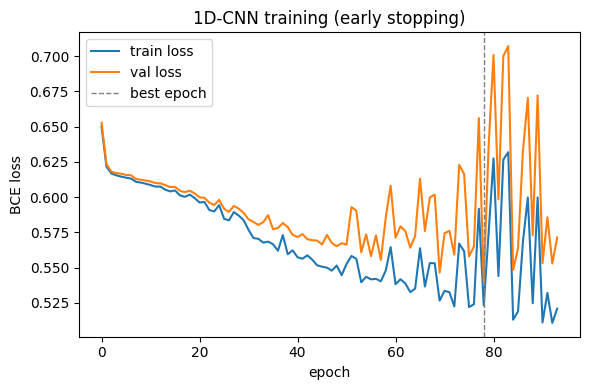

stopped after 94 epochs; best val loss at epoch 78


In [9]:
model, hist = fit_cnn(Xtr_all, ytr_all, return_history=True)
hist = np.array(hist)
plt.figure(figsize=(6, 4))
plt.plot(hist[:, 0], label="train loss")
plt.plot(hist[:, 1], label="val loss")
plt.axvline(hist[:, 1].argmin(), ls="--", c="grey", lw=1, label="best epoch")
plt.xlabel("epoch"); plt.ylabel("BCE loss"); plt.legend()
plt.title("1D-CNN training (early stopping)"); plt.tight_layout(); plt.show()
print(f"stopped after {len(hist)} epochs; best val loss at epoch {hist[:,1].argmin()}")

## 5. Test-set performance

In [10]:
def metrics(y, p):
    pred = (p >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    return {"ACC": accuracy_score(y, pred), "AUC": roc_auc_score(y, p),
            "MCC": matthews_corrcoef(y, pred), "F1": f1_score(y, pred),
            "SN": recall_score(y, pred), "SP": tn/(tn+fp), "Prec": precision_score(y, pred)}

test_p = predict(model, Xte)
pd.DataFrame({"1D-CNN": metrics(yte, test_p)}).T.round(3)

,ACC,AUC,MCC,F1,SN,SP,Prec
1D-CNN,0.663,0.723,0.354,0.737,0.903,0.4,0.622


*Reference: AAC floor 0.853 | RF 0.830 | XGBoost 0.857 (test AUC).*

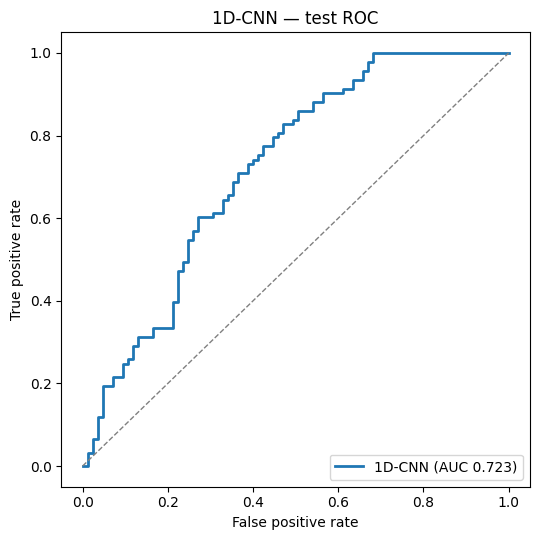

In [12]:
fpr, tpr, _ = roc_curve(yte, test_p)
plt.figure(figsize=(5.5, 5.5))
plt.plot(fpr, tpr, lw=2, label=f"1D-CNN (AUC {roc_auc_score(yte, test_p):.3f})")
plt.plot([0, 1], [0, 1], "--", c="grey", lw=1)
plt.xlabel("False positive rate") 
plt.ylabel("True positive rate")
plt.title("1D-CNN — test ROC")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 6. Out-of-fold predictions for the meta-learner

Same as the tree learners: 5-fold OOF probabilities on train (each fold predicted by a
CNN trained only on the other folds), so the stacking step stays leakage-free. This
retrains the small CNN five times, which is quick.

In [13]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
oof = np.zeros(len(ytr_all), dtype="float32")
for k, (tri, vali) in enumerate(skf.split(Xtr_all, ytr_all)):
    m = fit_cnn(Xtr_all[tri], ytr_all[tri], seed=SEED + k)
    oof[vali] = predict(m, Xtr_all[vali])
    print(f"fold {k+1} done")
print(f"CNN OOF train AUC {roc_auc_score(ytr_all, oof):.3f}  (optimistic; see note)")

fold 1 done
fold 2 done
fold 3 done
fold 4 done
fold 5 done
CNN OOF train AUC 0.790  (optimistic; see note)


## 7. Save model and predictions

In [14]:
import os
os.makedirs("models", exist_ok=True)
os.makedirs("predictions", exist_ok=True)

torch.save(model.state_dict(), "models/base_cnn.pt")
np.savez_compressed("predictions/base_cnn_predictions.npz",
                    cnn_oof=oof, cnn_test=test_p,
                    y_train=ytr_all, y_test=yte)
print("saved models/base_cnn.pt, predictions/base_cnn_predictions.npz")

saved models/base_cnn.pt, predictions/base_cnn_predictions.npz
